# Hotel Price Clustering Analysis (k-means)

This notebook uses k-means clustering to identify groups of hotels based on
price level, rating, and distance from city center.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)

# Loading Data

In [2]:
df = pd.read_csv('../data/enriched_hotels_data.csv')

print(f"Total records: {len(df)}")
print(f"Locations: {df['location'].unique()}")

df.head()

Total records: 1923
Locations: ['Arosa' 'Basel' 'Bern' 'Chur' 'Genf' 'Interlaken' 'Lausanne' 'Luzern'
 'St. Gallen' 'St. Moritz' 'Winterthur' 'Zermatt' 'Zuerich']


,search_date,day_of_week,location,hotel_id,hotel_name,price,currency,rating,address,city_code,...,is_school_vacation,temp_avg,temp_min,temp_max,precipitation_mm,snow_depth_cm,sunshine_hours,is_ski_season,hotel_chain,is_chain_hotel
0,05.01.2026,Monday,Arosa,BWZRH091,BEST WESTERN HOTEL ZURCHERHOF,570.64,CHF,4.5,"Poststrasse 95, Arosa",ZRH,...,False,-8.2,-11.3,-2.6,4.0,126,4.1,True,Best Western,True
1,05.01.2026,Monday,Arosa,MCZRHDTM,Zurich Marriott Hotel,732.90,CHF,4.5,"Marktplatz 10, Arosa",ZRH,...,False,-5.6,-11.0,-0.9,1.3,64,1.4,True,Marriott,True
2,05.01.2026,Monday,Arosa,ONZRHCTY,HOTEL CITY,438.36,CHF,4.3,"Hauptstrasse 54, Arosa",ZRH,...,False,-6.8,-12.6,-1.4,1.5,142,3.5,True,Independent,False
3,05.01.2026,Monday,Arosa,ONZRHMOT,HOTEL MONTANA,301.46,CHF,4.1,"Poststrasse 9, Arosa",ZRH,...,False,-9.5,-14.4,-5.1,0.0,94,1.3,True,Independent,False
4,05.01.2026,Monday,Arosa,XKZRH001,Hotel du Lac,239.68,CHF,3.9,"Bahnhofstrasse 13, Arosa",ZRH,...,False,-4.9,-9.0,1.9,1.6,131,2.9,True,Independent,False


# Defining Cluster

In [3]:
cluster_features = df[['price', 'rating', 'distance_from_center']].dropna()

print(f"Records used for clustering: {len(cluster_features)}")
cluster_features.head()

Records used for clustering: 1923


,price,rating,distance_from_center
0,570.64,4.5,107.47
1,732.90,4.5,108.23
2,438.36,4.3,107.95
3,301.46,4.1,108.41
4,239.68,3.9,107.36


# Standardizing

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

# Elbow Method

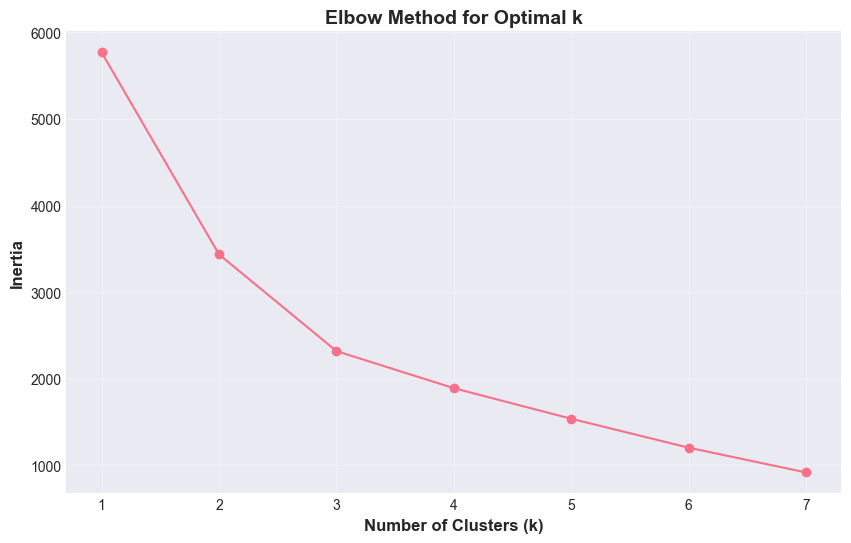

In [5]:
inertia = []
k_range = range(1, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
plt.ylabel('Inertia', fontsize=12, fontweight='bold')
plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

# Interpretation
The elbow suggests **k = 3**, which is used in the following analysis.

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

cluster_features['cluster'] = clusters
df_clustered = df.loc[cluster_features.index].copy()
df_clustered['cluster'] = clusters

# Visualization
**Price vs. Distance**

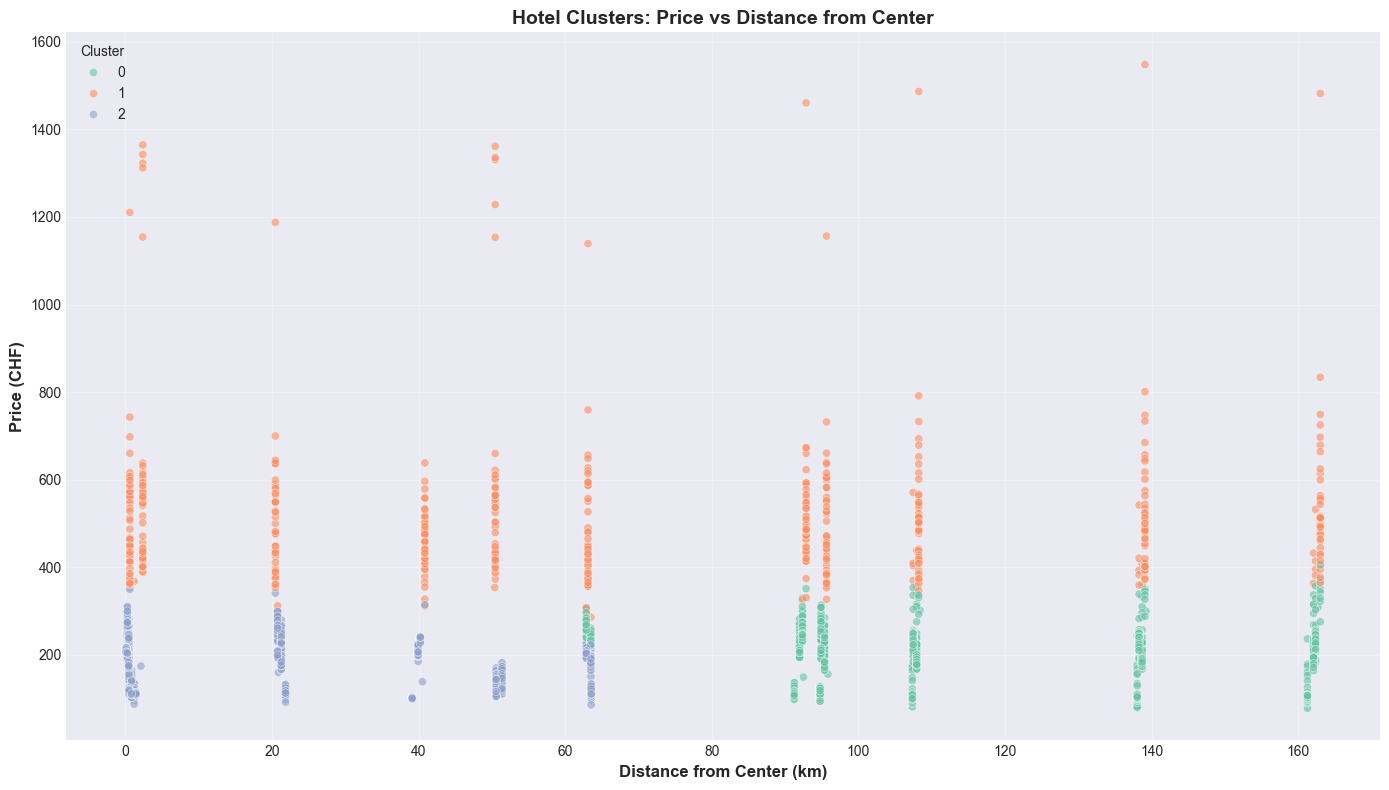

In [7]:
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=df_clustered,
    x='distance_from_center', 
    y='price',
    hue='cluster',
    palette='Set2',
    alpha=0.6
)

plt.xlabel('Distance from Center (km)', fontsize=12, fontweight='bold')
plt.ylabel('Price (CHF)', fontsize=12, fontweight='bold')
plt.title('Hotel Clusters: Price vs Distance from Center', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

**Price vs. Rating**

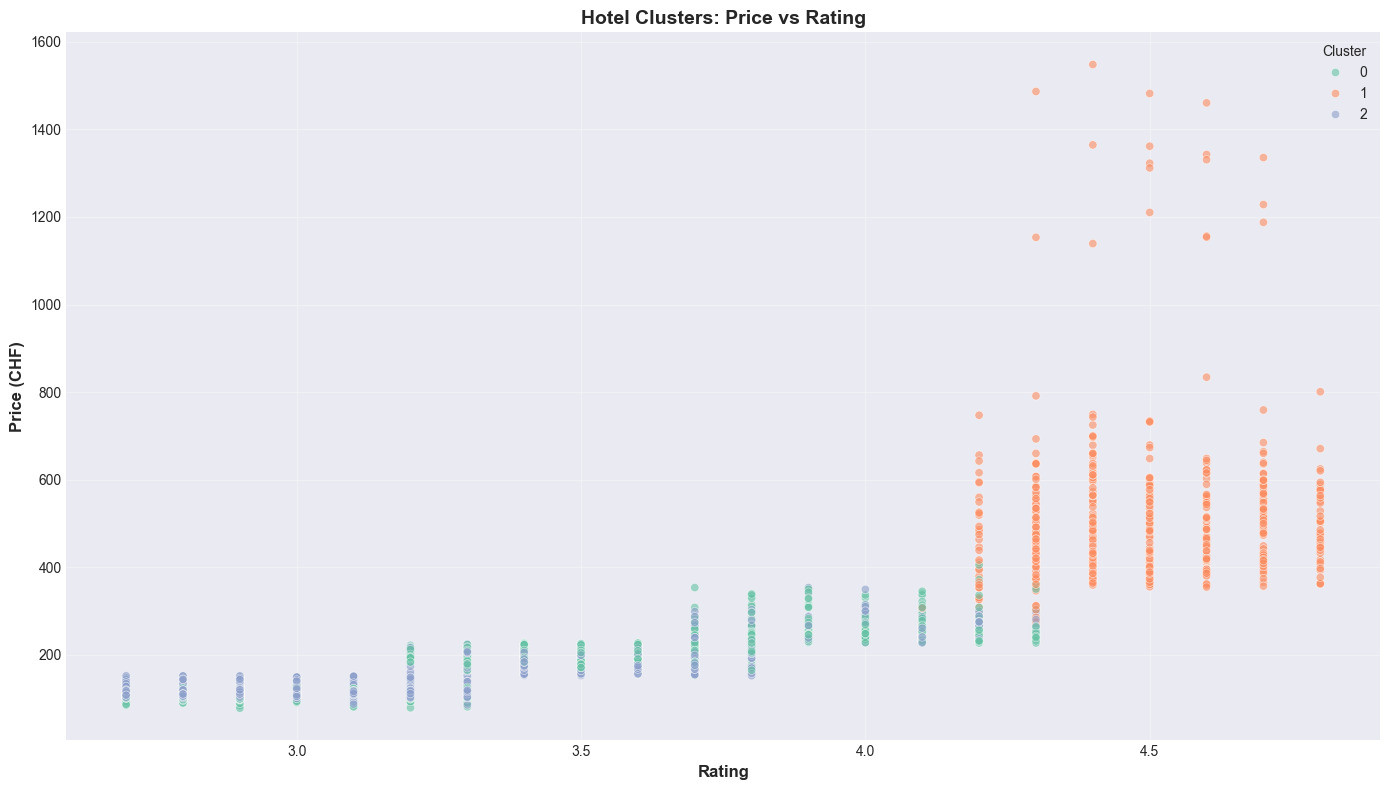

In [8]:
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=df_clustered,
    x='rating',
    y='price',
    hue='cluster',
    palette='Set2',
    alpha=0.6
)

plt.xlabel('Rating', fontsize=12, fontweight='bold')
plt.ylabel('Price (CHF)', fontsize=12, fontweight='bold')
plt.title('Hotel Clusters: Price vs Rating', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

# Cluster Interpretation

In [9]:
cluster_summary = df_clustered.groupby('cluster').agg({
    'price': ['mean', 'min', 'max'],
    'rating': 'mean',
    'distance_from_center': 'mean',
    'hotel_id': 'count'
    }).round(2)

cluster_summary.columns = [
    'Avg_Price', 'Min_Price', 'Max_Price',
    'Avg_Rating', 'Avg_Distance', 'Hotel_Count'
    ]

print("Cluster Summary:")
cluster_summary

Cluster Summary:


,Avg_Price,Min_Price,Max_Price,Avg_Rating,Avg_Distance,Hotel_Count
cluster,,,,,,
0,205.31,77.87,405.30,3.61,116.05,681
1,517.37,268.29,1548.06,4.49,70.53,494
2,175.59,85.68,353.62,3.40,23.45,748


# Interpretation

## Cluster Interpretation
- **Cluster 1:** Premium hotels – high price, high rating  
- **Cluster 0:** Mid-range hotels – medium price, far from center  
- **Cluster 2:** Budget hotels – low price, lower rating, close to center  

